In [1]:
pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
from typing import Dict
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
import json
import re

In [3]:
from pydantic import BaseModel, Field
from dotenv import load_dotenv

load_dotenv()

True

In [4]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [5]:
class PatientState(BaseModel):
    raw_input: str = Field(..., description="Raw patient complaint sheet")
    extracted_entities: dict | None = Field(default=None, description="Structured symptom extraction")
    clinical_findings: str | None = Field(default=None, description="Guideline based findings")
    risk_level: str | None = Field(default=None, description="LOW/ MEDIUM/ HIGH")
    care_path: str | None = Field(default=None, description="Recommended care method")
    doctor_summary: str | None = Field(default=None, description="Summary for doctor to analyse")

In [ ]:
def symptom_intake_agent(state: PatientState):
    print("Executing: Symptom Intake Agent")
    prompt = ChatPromptTemplate.from_template(
        """
        Extract structured mediccal information  from the patient input.
        Return ONLY valid JSON with age, gender, symptoms, duration, severity.
        Do not include any markdown formatting or code blocks.

        Patient Input:
        {input}
        """
    )

    response = llm.invoke(prompt.format(input=state.raw_input))
    content = response.content.strip()
    
    # Remove markdown code blocks if present
    if content.startswith("```"):
        content = re.sub(r'^```(?:json)?\s*', '', content)
        content = re.sub(r'\s*```$', '', content)
    
    # Parse JSON
    try:
        extracted_data = json.loads(content)
    except json.JSONDecodeError as e:
        # Fallback: try to extract JSON from the response
        json_match = re.search(r'\{.*\}', content, re.DOTALL)
        if json_match:
            extracted_data = json.loads(json_match.group())
        else:
            # If all else fails, create a basic structure
            extracted_data = {"error": "Failed to parse JSON", "raw_response": content}
    
    return {"extracted_entities": extracted_data}


def medical_knowledge_agent(state: PatientState):
    print("Executing: Medical Knowledge Agent")

    prompt = ChatPromptTemplate.from_template(
        """
        Based on the extracted symptoms, identify relavant clinical flags and 
        guideline based considerations. Do not diagnose.

        Extracted data:
        {entities}
        """
    )

    # Convert dict to string for prompt formatting
    entities_str = json.dumps(state.extracted_entities, indent=2) if state.extracted_entities else "None"
    response = llm.invoke(prompt.format(entities=entities_str))
    return {'clinical_findings': response.content}

def risk_identification_agent(state: PatientState):
    print("Executing: Risk Identification Agent")

    prompt = ChatPromptTemplate.from_template(
        """
        Classify patient risk consservatively as LOW, MEDIUM or HIGH
        Use clinical safety principles

        Findings:
        {findings}
        """
    )

    response = llm.invoke(prompt.format(findings=state.clinical_findings))
    return {'risk_level': response.content}

def urgent_care_agent(state: PatientState):
    print("Executing: Urgent Care Agent")
    return {'care_path': "Immediate emergency evaluation recommended."}

def routine_care_agent(state: PatientState):
    print("Executing: Routine Care Agent")
    return {'care_path': "Schedule routine GP or specialist consultation"}

def doctor_summary_agent(state: PatientState):
    print("Executing: Doctor Summary Agent")
    prompt = ChatPromptTemplate.from_template(
        """
        Generate a concise, clinician-ready, summary.

        Extracted_info: {entities}
        Clinical Findings: {findings}
        Risk-level: {risk}
        Recommended Care Path: {care}
        """
    )

    # Convert dict to string for prompt formatting
    entities_str = json.dumps(state.extracted_entities, indent=2) if state.extracted_entities else "None"
    
    response = llm.invoke(prompt.format(
        entities=entities_str,
        findings=state.clinical_findings or "None",
        risk=state.risk_level or "None",
        care=state.care_path or "None"
    ))

    return {"doctor_summary": response.content}


In [7]:
def risk_router(state: PatientState):
    if state.risk_level and "HIGH" in state.risk_level:
        return 'urgent'
    else:
        return 'routine'

In [9]:
workflow = StateGraph(PatientState)
workflow.add_node("symptom_intake_agent", symptom_intake_agent)
workflow.add_node("medical_knowledge_agent", medical_knowledge_agent)
workflow.add_node("risk_identification_agent", risk_identification_agent)
workflow.add_node('urgent_care_agent', urgent_care_agent)
workflow.add_node('routine_care_agent', routine_care_agent)
workflow.add_node('doctor_summary_agent', doctor_summary_agent)

workflow.set_entry_point('symptom_intake_agent')

workflow.add_edge('symptom_intake_agent', 'medical_knowledge_agent')
workflow.add_edge('medical_knowledge_agent', 'risk_identification_agent')
workflow.add_conditional_edges('risk_identification_agent', 
                            risk_router, 
                                {
                                    "urgent": "urgent_care_agent",
                                    "routine": "routine_care_agent"
                                })

workflow.add_edge('urgent_care_agent', 'doctor_summary_agent')
workflow.add_edge('routine_care_agent', 'doctor_summary_agent')
workflow.add_edge('doctor_summary_agent', END)

app = workflow.compile()

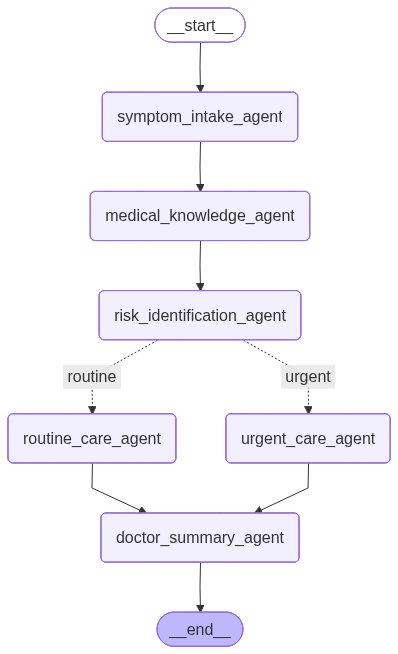

In [10]:
from IPython.display import Image, display
png_data = app.get_graph().draw_mermaid_png()
display(Image(data=png_data))

In [13]:
if __name__ == "__main__":
    input_state = {
    "raw_input": "60 year old male with chest pain, sweating, and shortness of breath for 2 hours"
    }


    result = app.invoke(input_state)
    print("\n--- FINAL OUTPUT ---\n")
    print(result["doctor_summary"])

Executing: Symptom Intake Agent
Executing: Medical Knowledge Agent
Executing: Risk Identification Agent
Executing: Urgent Care Agent
Executing: Doctor Summary Agent

--- FINAL OUTPUT ---

**Patient Summary:**

- **Age/Gender**: 60-year-old male
- **Symptoms**: 
  - Chest pain (duration: 2 hours)
  - Shortness of breath
  - Sweating (diaphoresis)

**Clinical Considerations:**
- **High Risk for Cardiovascular Events**: The combination of chest pain, shortness of breath, and sweating in a male patient of this age raises significant concern for acute coronary syndrome (ACS) or other serious conditions.
- **Urgent Evaluation Required**: Symptoms lasting 2 hours necessitate immediate medical assessment, including ECG and cardiac biomarkers.

**Risk Level**: **HIGH**

**Recommendations**:
- **Immediate Medical Attention**: Urgent evaluation and monitoring are critical to ensure patient safety and appropriate management.


In [15]:
print(result["doctor_summary"])

**Patient Summary:**

- **Age/Gender**: 60-year-old male
- **Symptoms**: 
  - Chest pain (duration: 2 hours)
  - Shortness of breath
  - Sweating (diaphoresis)

**Clinical Considerations:**
- **High Risk for Cardiovascular Events**: The combination of chest pain, shortness of breath, and sweating in a male patient of this age raises significant concern for acute coronary syndrome (ACS) or other serious conditions.
- **Urgent Evaluation Required**: Symptoms lasting 2 hours necessitate immediate medical assessment, including ECG and cardiac biomarkers.

**Risk Level**: **HIGH**

**Recommendations**:
- **Immediate Medical Attention**: Urgent evaluation and monitoring are critical to ensure patient safety and appropriate management.
